In [288]:
# -*- coding: utf-8 -*-
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
from scipy.interpolate import interp1d

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 150
plt.rcParams.update({"font.size": 10})

G = 1  # kpc (km/s)^2 / Msun

# ---------------------------------------------------------------------
# Helper: infer method and level from filename
# ---------------------------------------------------------------------
def infer_method_and_level(label):
    base = os.path.basename(label).lower()
    if "fmm" in base:
        method = "fmm"
        m = re.search(r"fmm[_\-]?(\d+)", base)
        lvl = int(m.group(1)) if m else None
    elif "mg" in base:
        method = "mg"
        lvl = None
    else:
        method = "unknown"
        lvl = None
    return method, lvl

# ---------------------------------------------------------------------
# Load direct potential from TXT
# ---------------------------------------------------------------------
def load_direct_phi(txt_file="./txt/direct_phi_xslice.txt"):
    data = np.loadtxt(txt_file)
    x_eval = data[:, 0]
    phi_eval = data[:, 1]
    return x_eval, phi_eval

# ---------------------------------------------------------------------
# Helper: regime boundaries
# ---------------------------------------------------------------------
def regime_boundaries(levelmin, level_amr_to_fmm, method, box_length=1.0, log_file=None, dx_round=True, n_far_levels=5):
    dx = box_length / (2 ** levelmin)
    r_direct = r_intermediate = None

    if log_file and os.path.exists(log_file):
        txt = open(log_file).read()
        m_direct = re.search(r"r_fmm_direct_max\s*=\s*([0-9.eE+-]+)", txt)
        m_inter = re.search(r"r_fmm_intermediate_max\s*=\s*([0-9.eE+-]+)", txt)
        if m_direct: r_direct = float(m_direct.group(1))
        if m_inter: r_intermediate = float(m_inter.group(1))

    if method.lower() == "fmm" and level_amr_to_fmm is not None:
        l_box = (2 ** level_amr_to_fmm) * dx
        if r_direct is None: r_direct = 2.0 * l_box
        if r_intermediate is None: r_intermediate = 4.0 * l_box

    if dx_round and dx > 0:
        if r_direct is not None:
            pix = max(1, round(r_direct / dx))
            r_direct = pix * dx
        if r_intermediate is not None:
            pix = max(int(np.ceil(r_direct / dx)) + 1 if r_direct else 2, round(r_intermediate / dx))
            r_intermediate = pix * dx

    far_bounds = []
    if r_intermediate is not None:
        prev = r_intermediate
        for i in range(n_far_levels):
            nxt = prev * 2.0
            far_bounds.append((prev, nxt))
            prev = nxt

    return r_direct, r_intermediate, far_bounds

# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
def load_data(filename1, filename2, out_dir="../out"):
    names = ["x", "y", "z", "fx", "fy", "fz", "phi"]
    file1 = os.path.join(out_dir, filename1)
    file2 = os.path.join(out_dir, filename2)

    df1 = pd.read_csv(file1, header=None, sep=r"\s+", names=names)
    df2 = pd.read_csv(file2, header=None, sep=r"\s+", names=names)

    for df in [df1, df2]:
        df["x"] -= df["x"].min()
        df["y"] -= df["y"].min()
        df["z"] -= df["z"].min()

    return df1, df2, filename1, filename2

# ---------------------------------------------------------------------
# 2D comparison plot
# ---------------------------------------------------------------------
def plot_2d(df1, df2, label1, label2, z_slice):
    df1_slice = df1[np.isclose(df1["z"], z_slice)]
    df2_slice = df2[np.isclose(df2["z"], z_slice)]

    grid1 = df1_slice.pivot(index="y", columns="x", values="phi")
    grid2 = df2_slice.pivot(index="y", columns="x", values="phi")

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    im0 = axs[0].imshow(grid1.values, origin="lower", cmap="viridis")
    axs[0].set_title(f"{label1}  (z={z_slice})")
    plt.colorbar(im0, ax=axs[0])

    im1 = axs[1].imshow(grid2.values, origin="lower", cmap="viridis")
    axs[1].set_title(f"{label2}  (z={z_slice})")
    plt.colorbar(im1, ax=axs[1])

    diff = grid2.values - grid1.values
    with np.errstate(divide="ignore", invalid="ignore"):
        rel_diff = np.where(grid1.values != 0, diff / grid1.values, 0)
    im2 = axs[2].imshow(rel_diff, origin="lower", cmap="coolwarm")
    axs[2].set_title("Relative Difference")
    plt.colorbar(im2, ax=axs[2])

    plt.tight_layout()
    os.makedirs("./fig", exist_ok=True)
    plt.savefig(f"./fig/compare_2d_{z_slice}_{label1}_vs_{label2}.png", dpi=200)
    plt.show()

# ---------------------------------------------------------------------
# Radial profile plot using direct potential
# ---------------------------------------------------------------------
def plot_profile(df1, df2, label1, label2, z_slice,
                 levelmin=7, level_amr_to_fmm=None,
                 box_length=1.0, n_far_levels=5, mode="x"):

    df1_slice = df1[np.isclose(df1["z"], z_slice)]
    df2_slice = df2[np.isclose(df2["z"], z_slice)]
    grid1 = df1_slice.pivot(index="y", columns="x", values="phi").values
    grid2 = df2_slice.pivot(index="y", columns="x", values="phi").values
    nx, ny = grid1.shape
    dx = box_length / (2 ** levelmin)
    xc_phys = box_length / 2.0
    yc_phys = box_length / 2.0
    zc_phys = (z_slice + 0.5) * dx

    if mode == "x":
        yc_idx = ny // 2
        x_phys = (np.arange(nx) + 0.5) * dx
        vals1_row = grid1[yc_idx, :]
        vals2_row = grid2[yc_idx, :]

        # 🔹 only take right side: x > midpoint (~63 for 128 grid)
        mid_idx = nx // 2
        x_phys = x_phys[mid_idx:]
        vals1_row = vals1_row[mid_idx:]
        vals2_row = vals2_row[mid_idx:]

        # distances from center for radial fit
        r_fit = np.abs(x_phys - xc_phys)

    elif mode == "diag":
        n_steps = min(nx, ny)
        x_idx = np.arange(n_steps)
        y_idx = np.arange(n_steps)
        vals1_row = np.array([grid1[y, x] for x, y in zip(x_idx, y_idx)])
        vals2_row = np.array([grid2[y, x] for x, y in zip(x_idx, y_idx)])
        x_phys = (x_idx + 0.5) * dx
        y_phys = (y_idx + 0.5) * dx
        r_fit = np.sqrt((x_phys - xc_phys)**2 + (y_phys - yc_phys)**2)
    else:
        raise ValueError("mode must be 'x' or 'diag'")

    # --------------------------------------------------------
    # Decide analytic reference: NFW vs single point potential
    # --------------------------------------------------------
    has_nfw    = "nfw" in label1.lower() or "nfw" in label2.lower()
    has_single = "single" in label1.lower() or "single" in label2.lower()
    
    # 🔹 Inconsistent case: both "nfw" and "single" appear
    assert not (has_nfw and has_single), (
        f"Inconsistent comparison: one file has 'nfw' and the other has 'single'.\n"
        f"label1={label1}, label2={label2}"
    )
    
    if has_nfw:
        # Load direct NFW potential profile
        x_direct, phi_direct = load_direct_phi("./txt/direct_phi_xslice.txt")
        phi_interp = interp1d(x_direct, phi_direct, bounds_error=False, fill_value="extrapolate")
        phi_nfw = phi_direct #phi_interp(r_fit)
        analytic_label = "NFW analytic"
    elif has_single:
        # Use simple -1/r potential
        phi_nfw = -1 / r_fit
        analytic_label = "Analytic -1/r"
    else:
        phi_nfw = None
        analytic_label = None


    # residuals
    with np.errstate(divide="ignore", invalid="ignore"):
        if phi_nfw is not None:
            resid1 = (vals1_row - phi_nfw) / phi_nfw
            resid2 = (vals2_row - phi_nfw) / phi_nfw
        else:
            resid1 = (vals1_row + 1 / r_fit) / (-1 / r_fit)
            resid2 = (vals2_row + 1 / r_fit) / (-1 / r_fit)

    resid_pct1 = 100 * resid1
    resid_pct2 = 100 * resid2
    resid_abs1 = np.abs(resid1)
    resid_abs2 = np.abs(resid2)

    # regimes
    method1, lvl1 = infer_method_and_level(label1)
    method2, lvl2 = infer_method_and_level(label2)
    lvl1_use = level_amr_to_fmm if (level_amr_to_fmm is not None and method1=="fmm") else lvl1
    lvl2_use = level_amr_to_fmm if (level_amr_to_fmm is not None and method2=="fmm") else lvl2
    log1 = label1.replace(".out", ".log")
    log2 = label2.replace(".out", ".log")
    r_direct1, r_inter1, far1 = regime_boundaries(levelmin, lvl1_use, method1, box_length, log1, n_far_levels=n_far_levels)
    r_direct2, r_inter2, far2 = regime_boundaries(levelmin, lvl2_use, method2, box_length, log2, n_far_levels=n_far_levels)

    if mode=='diag':
        try:
            r_direct1, r_inter1 = r_direct1 * np.sqrt(3), r_inter1 * np.sqrt(3)
            r_direct2, r_inter2 = r_direct2 * np.sqrt(3), r_inter2 * np.sqrt(3)
        except:
            pass

    # --------------------------------------------------------
    # Plotting with improved style
    # --------------------------------------------------------
    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1, figsize=(6.5, 8.5),
        gridspec_kw={"height_ratios": [3, 1, 1]},
        sharex=True
    )

    # ---------------------------
    # (1) Potential profiles
    # ---------------------------
    ax1.loglog(r_fit, np.abs(vals1_row), "o", ms=3, alpha=0.6, label=f"|{label1}|", color="tab:blue")
    ax1.loglog(r_fit, np.abs(vals2_row), "o", ms=3, alpha=0.6, label=f"|{label2}|", color="tab:orange")

    if phi_nfw is not None:
        ax1.loglog(r_fit, np.abs(phi_nfw), "k--", lw=1.2, label=analytic_label)

    ax1.set_ylabel(r"$|\Phi|$", fontsize=12)
    ax1.set_title(f"Radial Potential Profile ({mode}-direction)", fontsize=11)
    ax1.legend(loc="best", fontsize=8, frameon=False)
    ax1.grid(True, which="both", ls="--", lw=0.4, alpha=0.3)

    # --- Regime shading ---
    def shade_regime(ax, r_d, r_i, far, color):
        if r_d:
            ax.axvline(r_d, color=color, lw=1.2, ls="--", alpha=0.6)
        if r_i:
            ax.axvline(r_i, color=color, lw=1.2, ls=":", alpha=0.6)
        for i, (rmin, rmax) in enumerate(far[:3]):  # only show first few far levels
            ax.axvspan(rmin, rmax, color=color, alpha=0.05 * (3 - i), lw=0)

    shade_regime(ax1, r_direct1, r_inter1, far1, "tab:blue")
    shade_regime(ax1, r_direct2, r_inter2, far2, "tab:orange")

    # ---------------------------
    # (2) Percent residual
    # ---------------------------
    ax2.plot(r_fit, resid_pct1, color="tab:blue", lw=0.8, alpha=0.8, label=f"{label1}")
    ax2.plot(r_fit, resid_pct2, color="tab:orange", lw=0.8, alpha=0.8, label=f"{label2}")
    ax2.axhline(0, color="k", lw=0.8, alpha=0.7)

    ax2.set_xscale("log")
    ax2.set_ylabel("Residual [%]", fontsize=11)
    ax2.legend(loc="upper right", fontsize=8, frameon=False)
    ax2.grid(True, which="both", ls="--", lw=0.4, alpha=0.3)
    ax2.set_ylim(-5, 5)

    # reuse regime lines for consistency
    shade_regime(ax2, r_direct1, r_inter1, far1, "tab:blue")
    shade_regime(ax2, r_direct2, r_inter2, far2, "tab:orange")

    # ---------------------------
    # (3) Log absolute residual
    # ---------------------------
    ax3.semilogx(r_fit, np.log10(resid_abs1 + 1e-12), color="tab:blue", lw=0.8, label=f"{label1}")
    ax3.semilogx(r_fit, np.log10(resid_abs2 + 1e-12), color="tab:orange", lw=0.8, label=f"{label2}")
    ax3.set_xlabel("r [kpc]", fontsize=12)
    ax3.set_ylabel(r"$\log_{10}|\mathrm{Residual}|$", fontsize=11)
    ax3.legend(loc="upper right", fontsize=8, frameon=False)
    ax3.grid(True, which="both", ls="--", lw=0.4, alpha=0.3)

    shade_regime(ax3, r_direct1, r_inter1, far1, "tab:blue")
    shade_regime(ax3, r_direct2, r_inter2, far2, "tab:orange")

    # ---------------------------
    plt.tight_layout(h_pad=0.5)
    os.makedirs("./fig", exist_ok=True)
    safe1 = os.path.splitext(os.path.basename(label1))[0]
    safe2 = os.path.splitext(os.path.basename(label2))[0]
    plt.savefig(f"./fig/profile_{safe1}_vs_{safe2}_{mode}.png", dpi=250, bbox_inches="tight")
    plt.show()



          x   y   z     fx     fy     fz       phi
1527088  64  64  64 -721.3 -712.8 -716.8 -121600.0


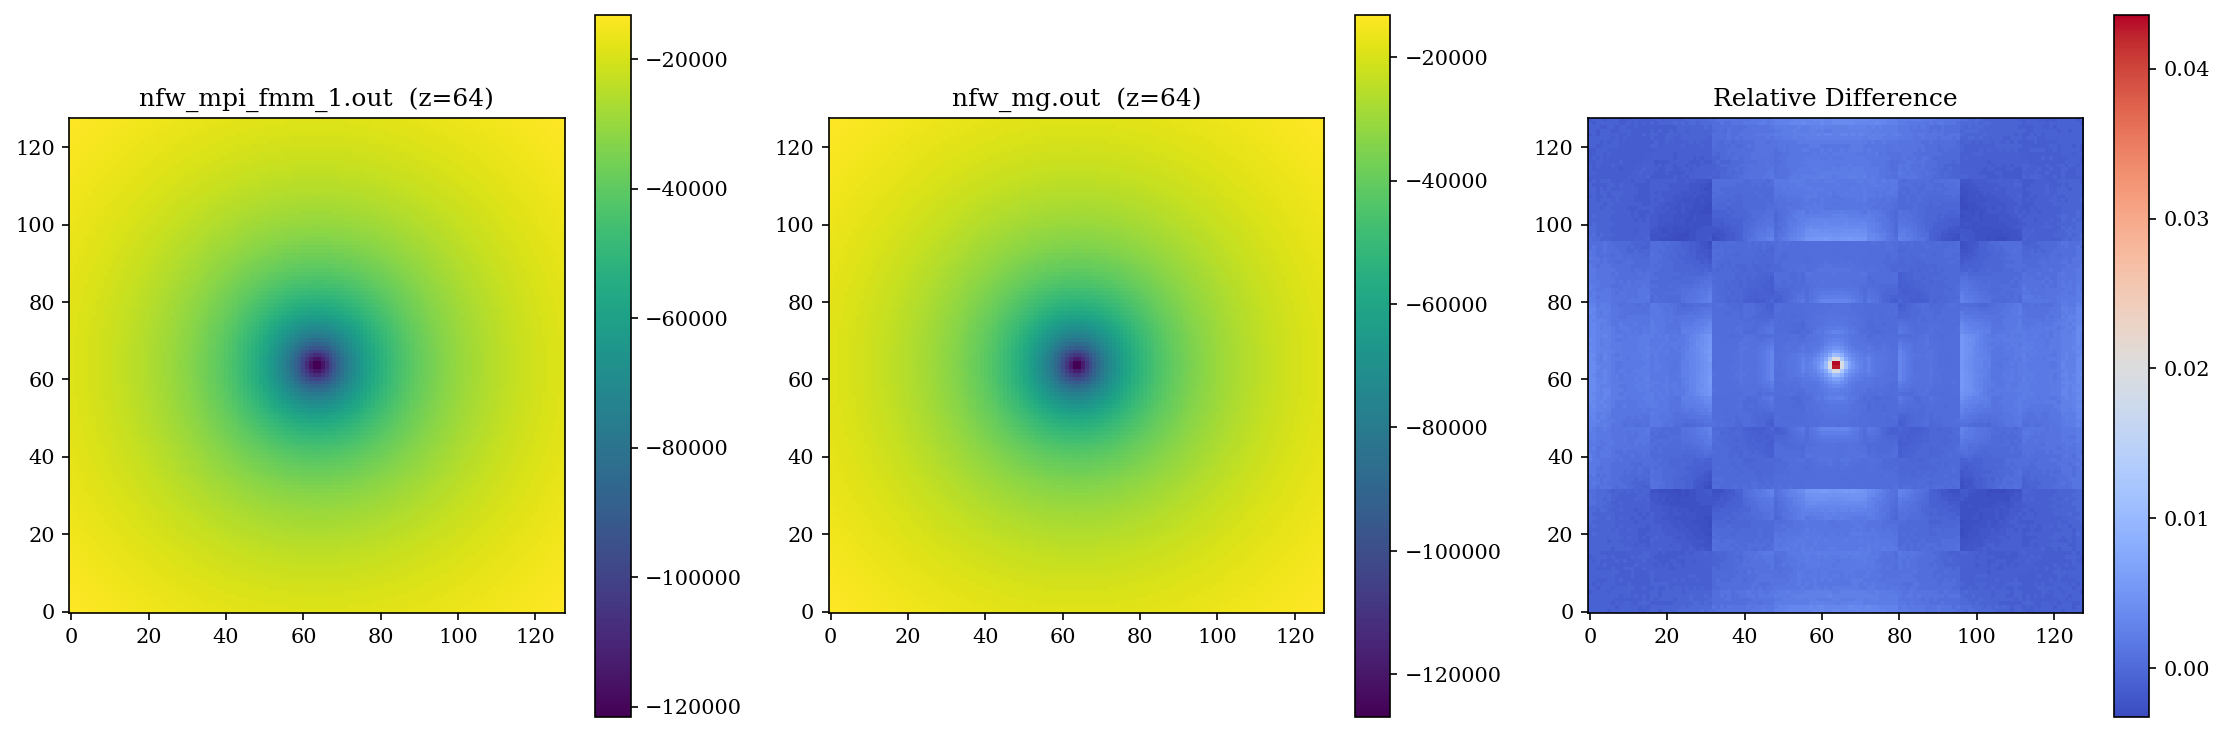

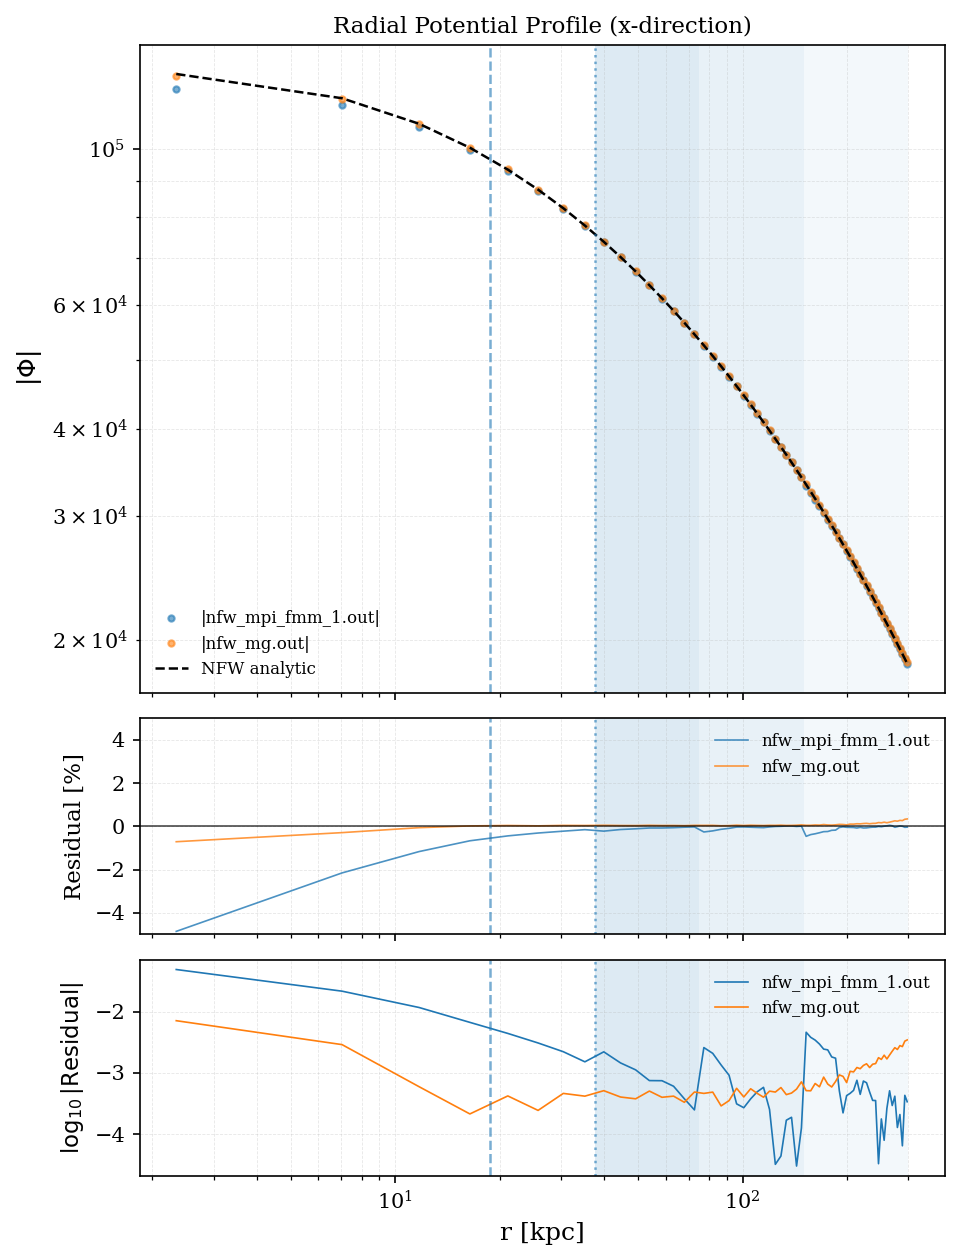

In [296]:
file1 = "nfw_mpi_fmm_1.out"
file2 = "nfw_mg.out"  # if filename contains "nfw", overlay NFW analytic
z_slice = 64
df1, df2, label1, label2 = load_data(file1, file2)
print(df1[(df1["x"] == 64) & (df1["y"] == 64) & (df1["z"] == 64)])
plot_2d(df1, df2, label1, label2, z_slice)

# x-direction profile
plot_profile(df1, df2, label1, label2, z_slice, levelmin=7, box_length=600, level_amr_to_fmm=None, mode="x")

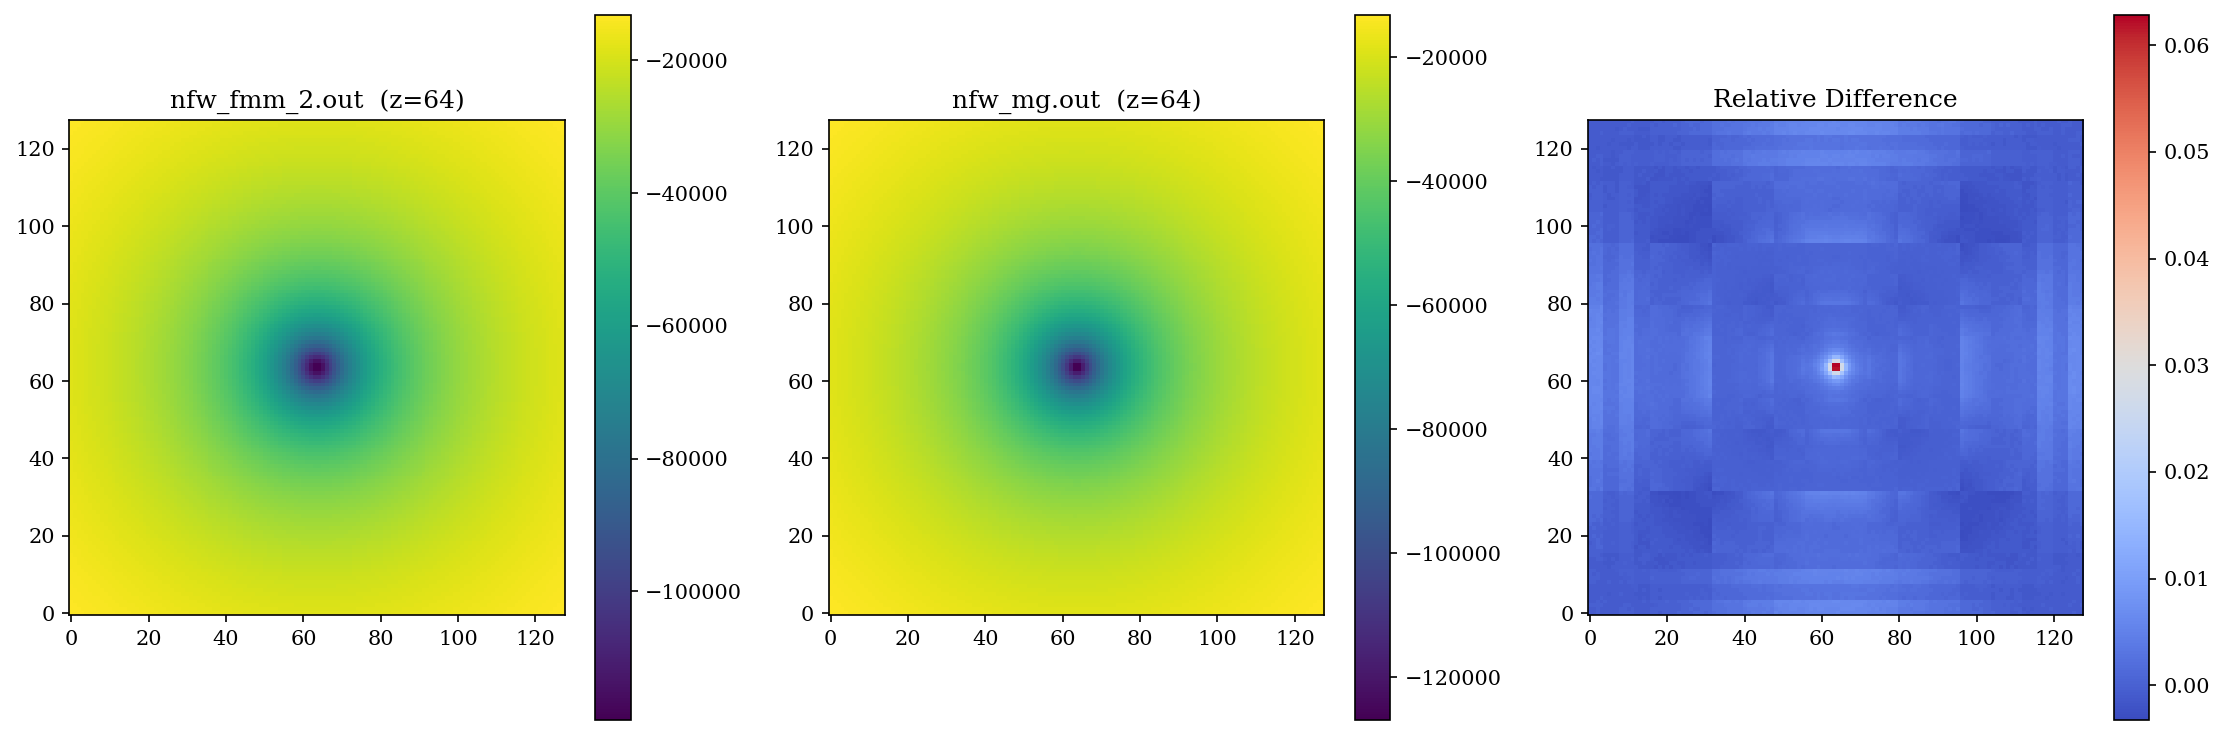

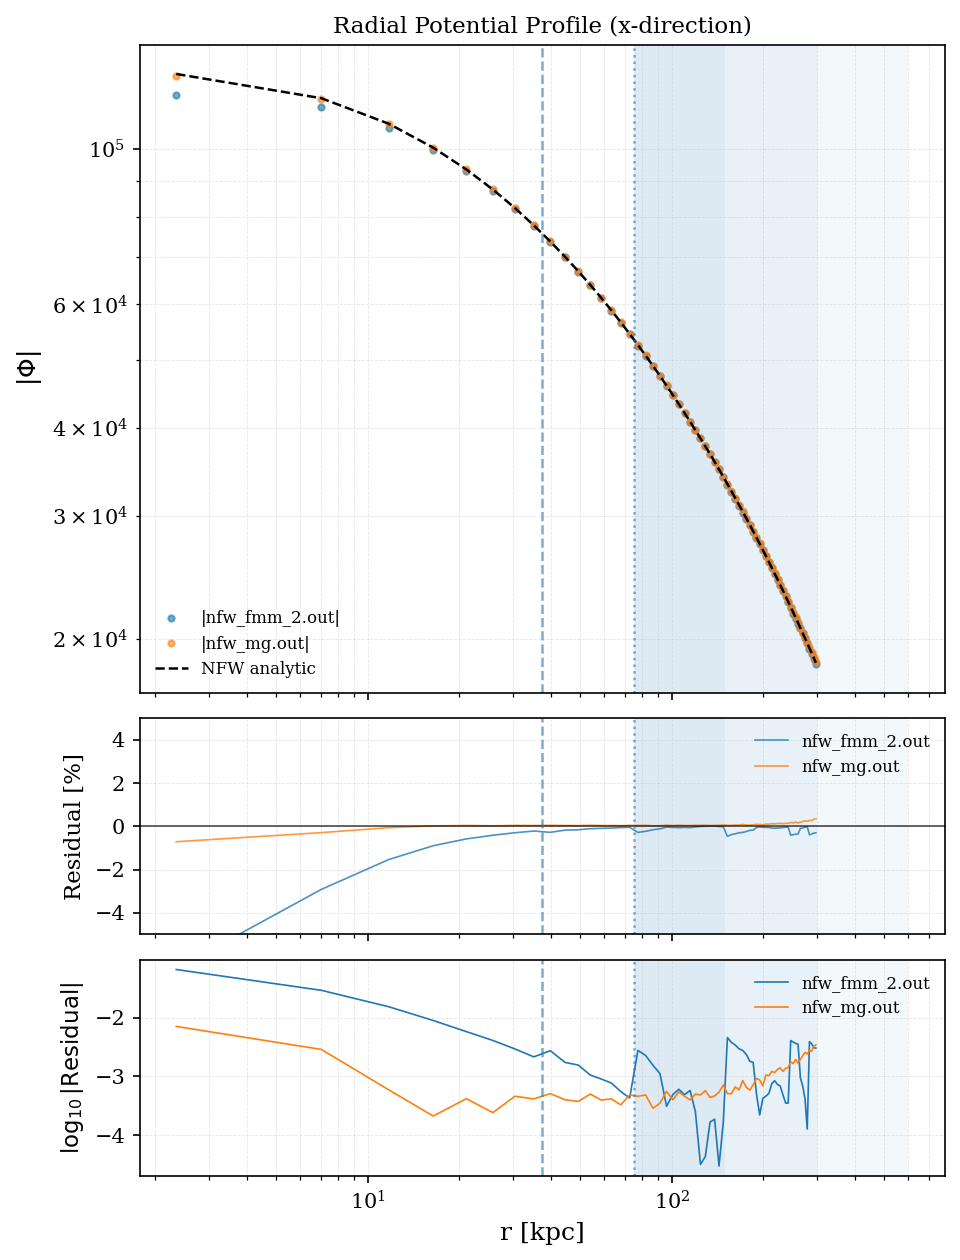

In [200]:
file1 = "nfw_fmm_2.out"
file2 = "nfw_mg.out"  # if filename contains "nfw", overlay NFW analytic
z_slice = 64

df1, df2, label1, label2 = load_data(file1, file2)
plot_2d(df1, df2, label1, label2, z_slice)

# x-direction profile
plot_profile(df1, df2, label1, label2, z_slice, levelmin=7, box_length=600, level_amr_to_fmm=None, mode="x")

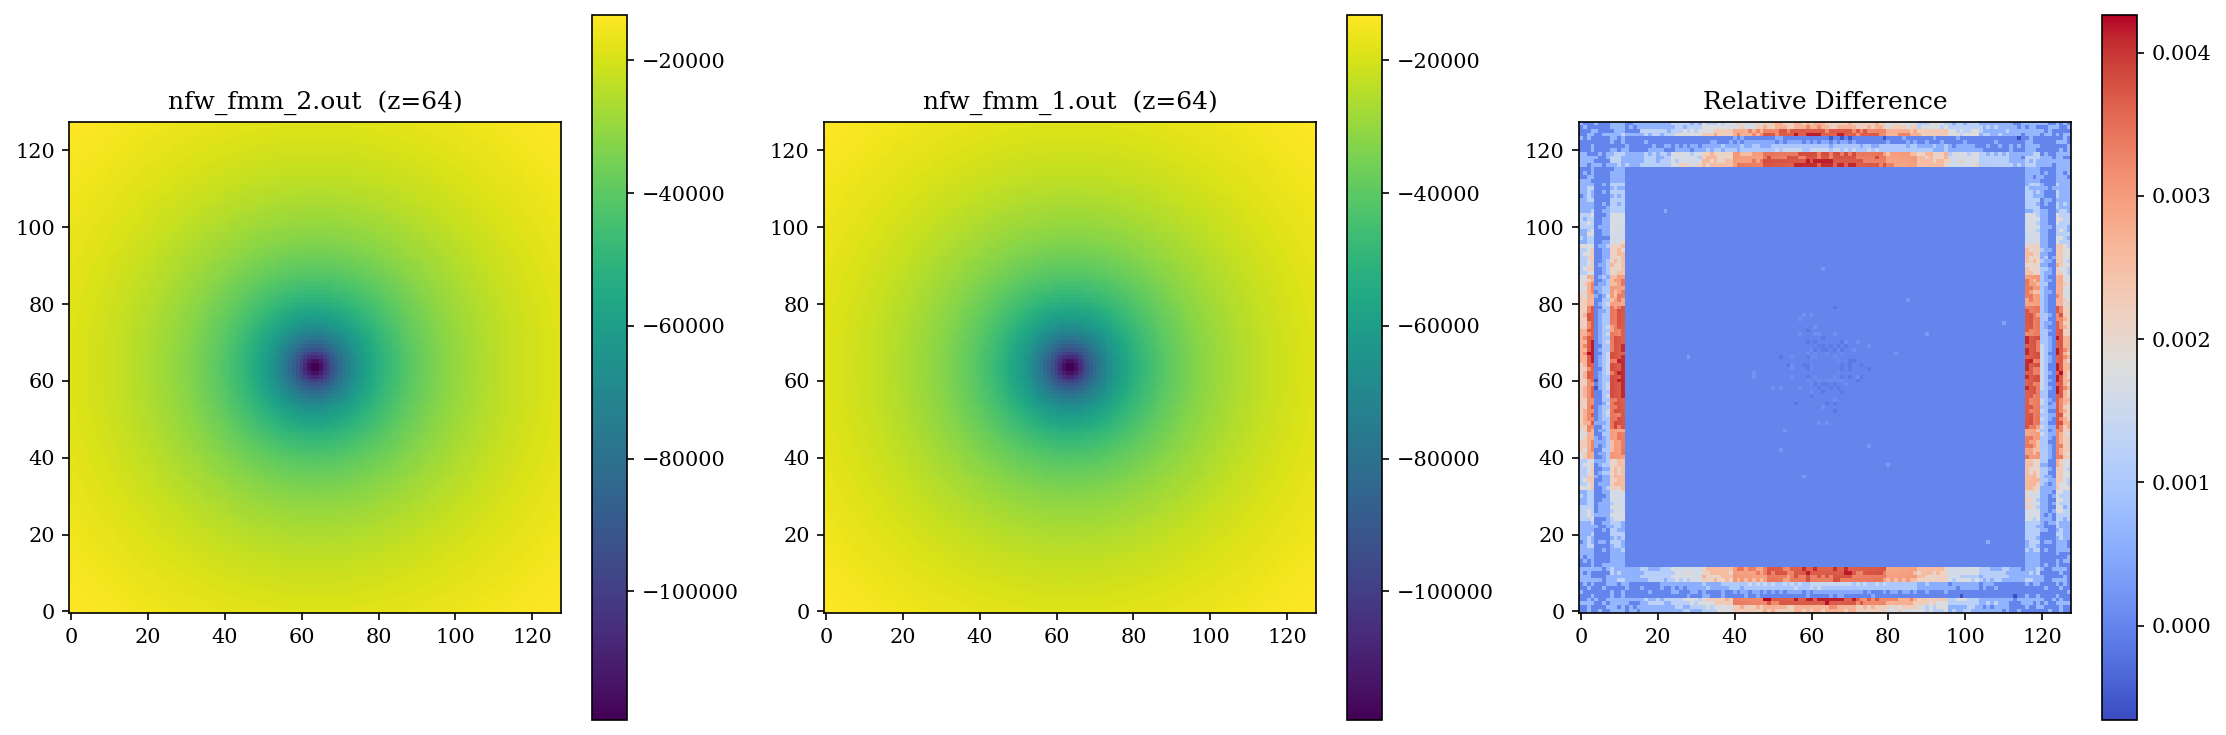

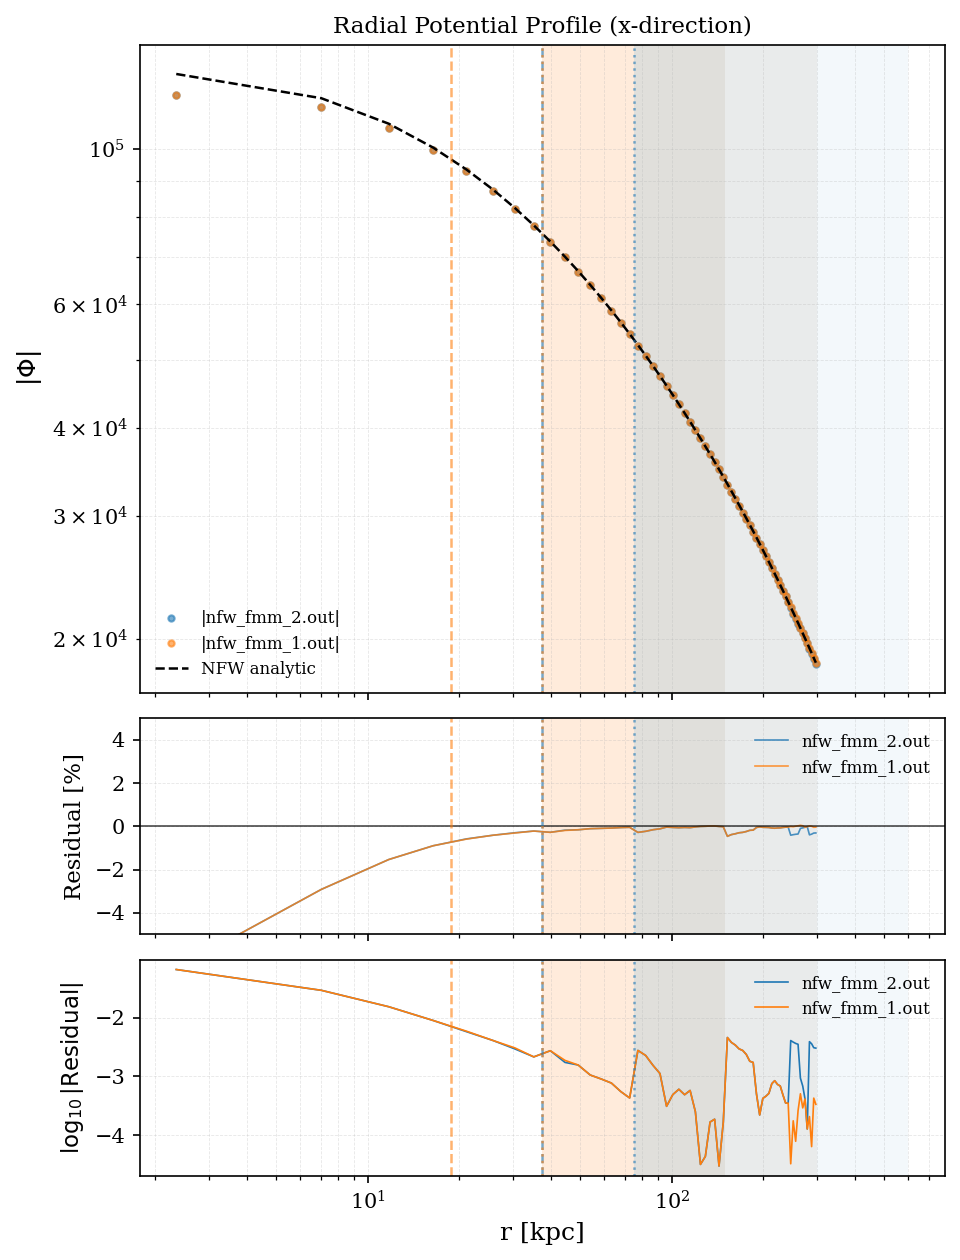

In [201]:
file1 = "nfw_fmm_2.out"
file2 = "nfw_fmm_1.out"  # if filename contains "nfw", overlay NFW analytic
z_slice = 64

df1, df2, label1, label2 = load_data(file1, file2)
plot_2d(df1, df2, label1, label2, z_slice)

# x-direction profile
plot_profile(df1, df2, label1, label2, z_slice, levelmin=7, box_length=600, level_amr_to_fmm=None, mode="x")

          x   y   z     fx     fy     fz    phi
1527088  64  64  64 -940.4 -940.4 -940.4 -91.18


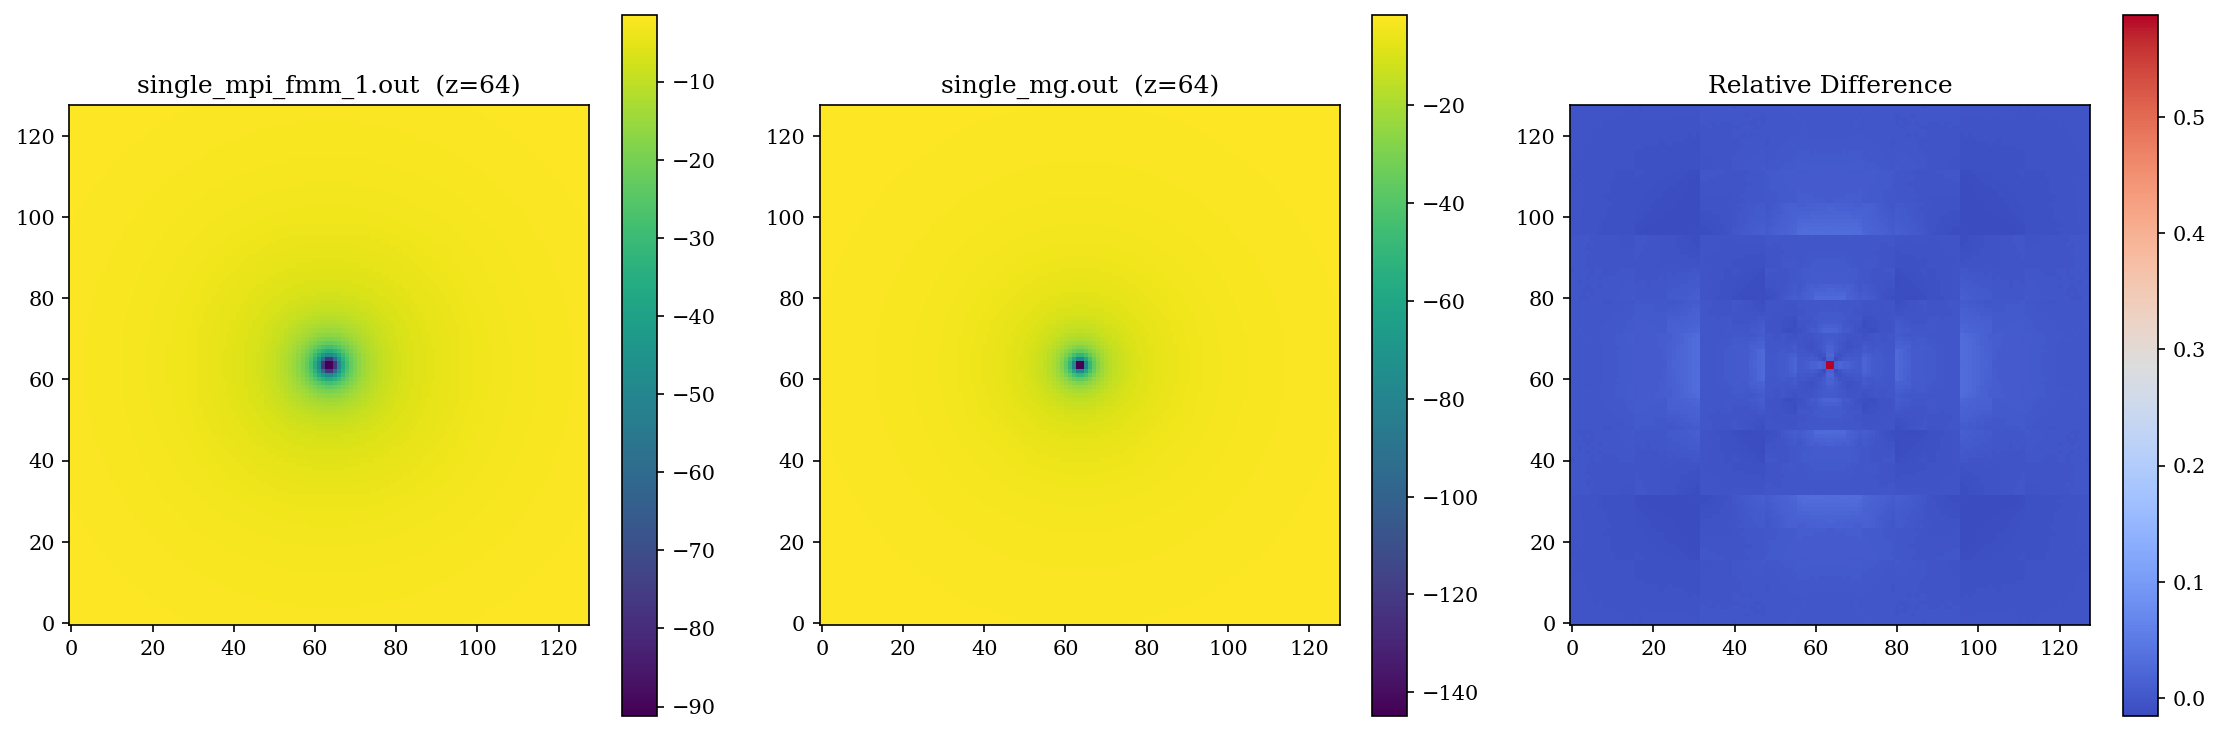

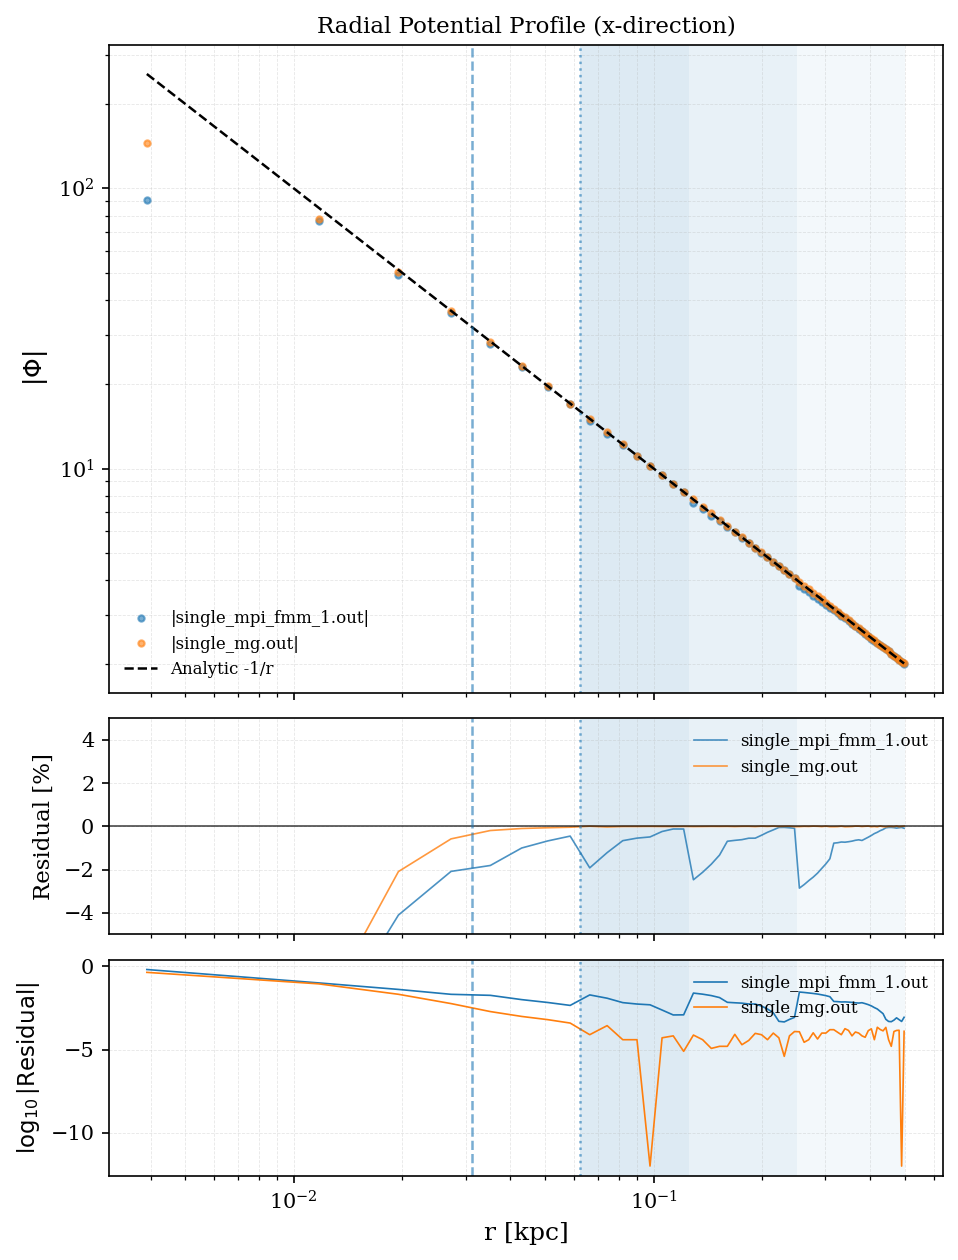

In [298]:
file1 = "single_mpi_fmm_1.out"
file2 = "single_mg.out"  # if filename contains "nfw", overlay NFW analytic
z_slice = 64

df1, df2, label1, label2 = load_data(file1, file2)
print(df1[(df1["x"] == 64) & (df1["y"] == 64) & (df1["z"] == 64)])

plot_2d(df1, df2, label1, label2, z_slice)
# x-direction profile
plot_profile(df1, df2, label1, label2, z_slice, levelmin=7, level_amr_to_fmm=None, mode="x")

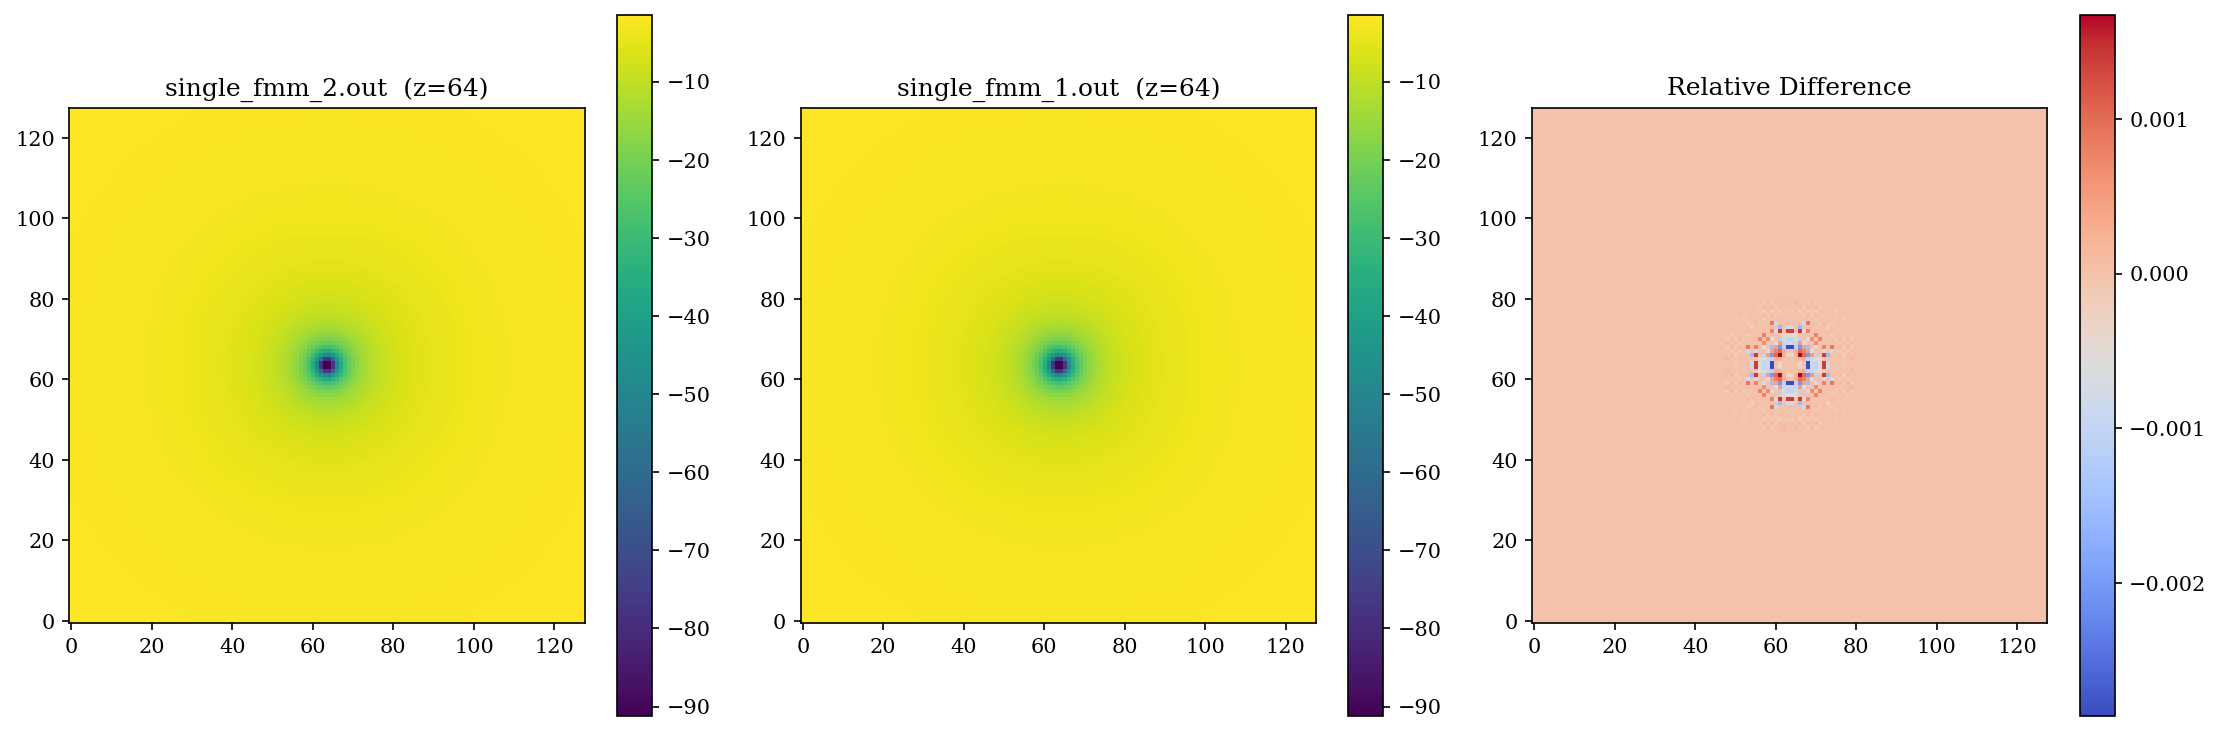

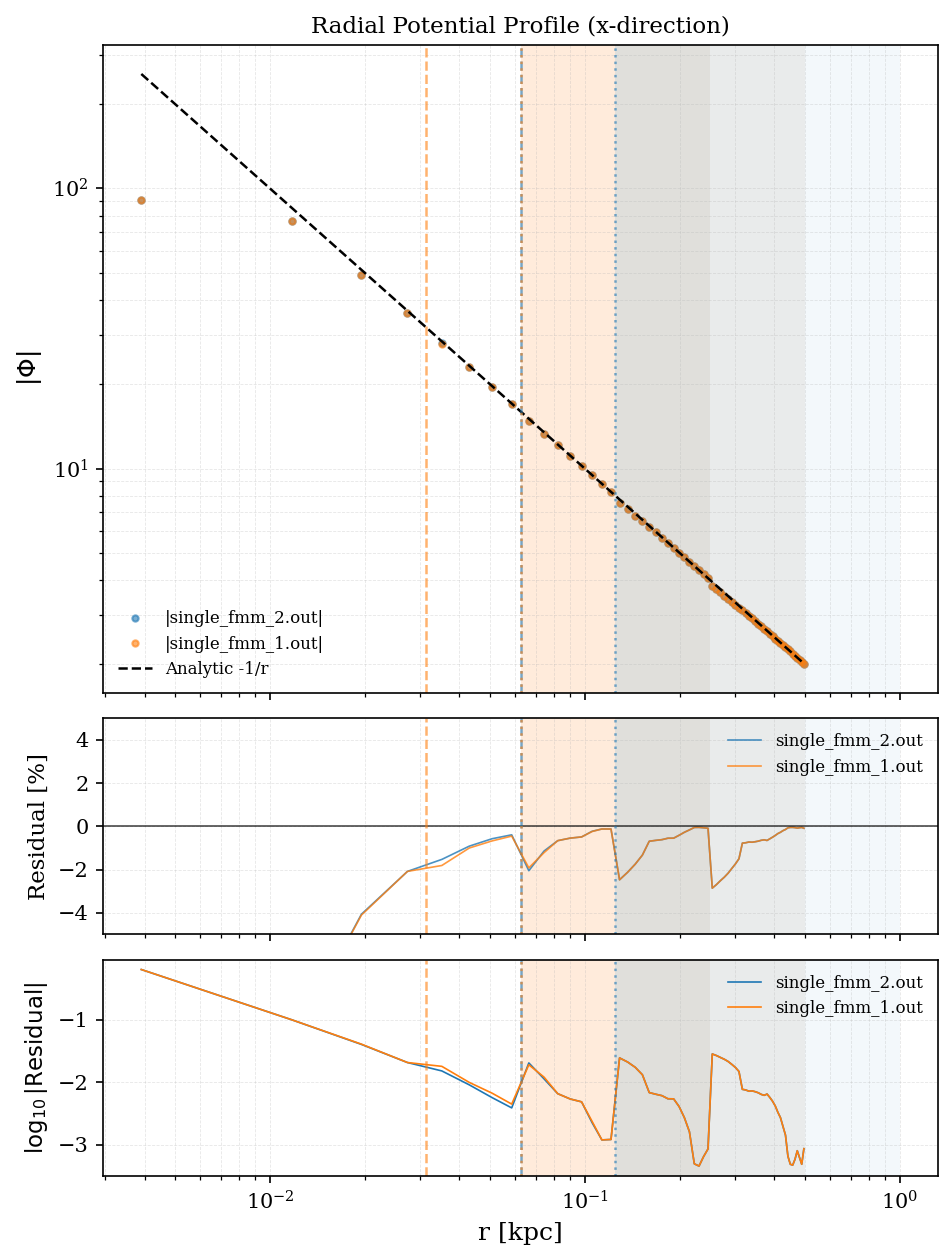

In [203]:
file1 = "single_fmm_2.out"
file2 = "single_fmm_1.out"  # if filename contains "nfw", overlay NFW analytic
z_slice = 64

df1, df2, label1, label2 = load_data(file1, file2)
plot_2d(df1, df2, label1, label2, z_slice)

# x-direction profile
plot_profile(df1, df2, label1, label2, z_slice, levelmin=7, box_length=1, level_amr_to_fmm=None, mode="x")

In [291]:
# -*- coding: utf-8 -*-
import numpy as np
import os

# -------------------------------
# Parameters
# -------------------------------
ic_file = "../nfw/ic_part"   # columns: x y z vx vy vz m
box_cut = 300.0               # kpc, cube: [-box_cut, box_cut]^3
G = 1.0                       # gravitational constant in kpc (km/s)^2 / Msun
z_cell = 63                    # slice index along z (0..63)
y_cell = 63                    # slice index along y (0..63)
n_points = 64                  # number of x points along x>0
N_cells = 64                   # total number of cells along one axis

# -------------------------------
# Load particle data
# -------------------------------
data = np.loadtxt(ic_file)
x, y, z, vx, vy, vz, m = data.T

# -------------------------------
# Mask particles inside the box
# -------------------------------
mask = (x >= -box_cut) & (x <= box_cut) & \
       (y >= -box_cut) & (y <= box_cut) & \
       (z >= -box_cut) & (z <= box_cut)

x_particles = x[mask]
y_particles = y[mask]
z_particles = z[mask]
m_particles = m[mask]
# -------------------------------
# Cell-centered x positions from 0 to 63
# -------------------------------
x_eval_cells = np.arange(n_points)   # 0..63
dx_cell = 2 * box_cut / (2*N_cells)   # size of a cell in kpc
x_eval_phys = x_eval_cells * dx_cell + dx_cell/2  # physical center of each cell along x>0
y_eval_phys = 0.5 * dx_cell      # physical y center
z_eval_phys = 0.5 * dx_cell     # physical z center


# -------------------------------
# Direct potential sum along x
# -------------------------------
phi_eval = np.zeros_like(x_eval_phys)

for i, xi in enumerate(x_eval_phys):
    dx = xi - x_particles
    dy = y_eval_phys - y_particles
    dz = z_eval_phys - z_particles
    r = np.sqrt(dx**2 + dy**2 + dz**2)
    r[r == 0] = 1e-10   # avoid division by zero
    phi_eval[i] = - np.sum(G * m_particles / r)

# -------------------------------
# Save to file
# -------------------------------
print(x_eval_phys)
os.makedirs("./txt", exist_ok=True)
out_file = "./txt/direct_phi_xslice.txt"
np.savetxt(out_file, np.column_stack([x_eval_phys, phi_eval]),
           header="x[kpc]  phi[kpc (km/s)^2]", fmt="%.6e")
print(f"Saved direct potential to {out_file}")

[  2.34375   7.03125  11.71875  16.40625  21.09375  25.78125  30.46875
  35.15625  39.84375  44.53125  49.21875  53.90625  58.59375  63.28125
  67.96875  72.65625  77.34375  82.03125  86.71875  91.40625  96.09375
 100.78125 105.46875 110.15625 114.84375 119.53125 124.21875 128.90625
 133.59375 138.28125 142.96875 147.65625 152.34375 157.03125 161.71875
 166.40625 171.09375 175.78125 180.46875 185.15625 189.84375 194.53125
 199.21875 203.90625 208.59375 213.28125 217.96875 222.65625 227.34375
 232.03125 236.71875 241.40625 246.09375 250.78125 255.46875 260.15625
 264.84375 269.53125 274.21875 278.90625 283.59375 288.28125 292.96875
 297.65625]
Saved direct potential to ./txt/direct_phi_xslice.txt


In [234]:
# -*- coding: utf-8 -*-
import numpy as np
import os

# -------------------------------
# Parameters
# -------------------------------
ic_file = "../nfw/ic_part"   # columns: x y z vx vy vz m
box_cut = 300.0              # kpc, cube: [-box_cut, box_cut]^3
G = 1.0                      # gravitational constant in kpc (km/s)^2 / Msun
level = 7                     # 2^level cells per axis
n_eval = 64                   # number of x points along x>0
dx_cell = 2 * box_cut / 2**level

# -------------------------------
# Load particle data
# -------------------------------
data = np.loadtxt(ic_file)
x, y, z, vx, vy, vz, m = data.T

# -------------------------------
# Mask particles inside the box
# -------------------------------
mask = (x >= -box_cut) & (x <= box_cut) & \
       (y >= -box_cut) & (y <= box_cut) & \
       (z >= -box_cut) & (z <= box_cut)

x_particles = x[mask]
y_particles = y[mask]
z_particles = z[mask]
m_particles = m[mask]

# -------------------------------
# Deposit mass into 128^3 cells
# -------------------------------
N_cells = 2**level
grid = np.zeros((N_cells, N_cells, N_cells))

# particle indices in cell grid
ix = np.floor((x_particles + box_cut) / dx_cell).astype(int)
iy = np.floor((y_particles + box_cut) / dx_cell).astype(int)
iz = np.floor((z_particles + box_cut) / dx_cell).astype(int)

# safety clamp
ix = np.clip(ix, 0, N_cells-1)
iy = np.clip(iy, 0, N_cells-1)
iz = np.clip(iz, 0, N_cells-1)

for i, j, k, mi in zip(ix, iy, iz, m_particles):
    grid[i, j, k] += mi

# -------------------------------
# Cell centers
# -------------------------------
x_centers = (np.arange(N_cells) + 0.5) * dx_cell - box_cut
y_centers = (np.arange(N_cells) + 0.5) * dx_cell - box_cut
z_centers = (np.arange(N_cells) + 0.5) * dx_cell - box_cut

# -------------------------------
# Evaluation points along x>0 (right half)
# -------------------------------
x_eval_cells = np.arange(N_cells//2)  # 0..63
x_eval_phys = x_centers[N_cells//2:]  # physical x positions
y_eval_phys = y_centers[N_cells//2]   # slice in middle
z_eval_phys = z_centers[N_cells//2]   # slice in middle

# -------------------------------
# Compute potential along x>0
# -------------------------------
phi_eval = np.zeros_like(x_eval_phys)

# Flatten grid for convenience
ix_flat, iy_flat, iz_flat = np.indices(grid.shape)
x_src = x_centers[ix_flat.ravel()]
y_src = y_centers[iy_flat.ravel()]
z_src = z_centers[iz_flat.ravel()]
m_src = grid.ravel()

# Only keep nonzero mass cells
mask_nonzero = m_src > 0
x_src = x_src[mask_nonzero]
y_src = y_src[mask_nonzero]
z_src = z_src[mask_nonzero]
m_src = m_src[mask_nonzero]

for i, xi in enumerate(x_eval_phys):
    dx = xi - x_src
    dy = y_eval_phys - y_src
    dz = z_eval_phys - z_src
    r = np.sqrt(dx**2 + dy**2 + dz**2)
    r[r == 0] = np.inf
    phi_eval[i] = - np.sum(G * m_src / r)

# -------------------------------
# Save to file
# -------------------------------
os.makedirs("./txt", exist_ok=True)
out_file = "./txt/direct_phi_xslice_grid.txt"
np.savetxt(out_file, np.column_stack([x_eval_phys, phi_eval]),
           header="x[kpc]  phi[kpc (km/s)^2]", fmt="%.6e")
print(f"Saved direct potential to {out_file}")


Saved direct potential to ./txt/direct_phi_xslice_grid.txt


In [239]:
print(y_eval_phys/(600/128))

0.5
